## Telco Customer Churn - Data Preprocessing


#import Packeges

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler


 1. Load the dataset

In [68]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2. Standardize column names

        To keep the analysis consistent, all column names are converted to lowercase.

In [69]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

3. Explore variable types

        Identify categorical variables, numerical variables, and the target variable.

In [71]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

target = "churn"

if target in categorical_cols:
    categorical_cols.remove(target)

print("Categorical variables:")
print(categorical_cols)

print("\nNumerical variables:")
print(numerical_cols)

print("\nTarget variable:")
print(target)

Categorical variables:
['customerid', 'gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']

Numerical variables:
['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']

Target variable:
churn


5. Handle missing values and data inconsistencies

        The `totalcharges` column contains blank values and needs conversion to numeric format.

In [70]:
print("Blank values in totalcharges:")
print((df["totalcharges"] == " ").sum())

df["totalcharges"] = df["totalcharges"].replace(" ", pd.NA)
df["totalcharges"] = pd.to_numeric(df["totalcharges"])

print("\nMissing values after conversion:")
print(df.isnull().sum())

df = df.dropna()

print("\nDataset shape after removing missing rows:")
print(df.shape)

Blank values in totalcharges:
11

Missing values after conversion:
customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

Dataset shape after removing missing rows:
(7032, 21)


6. Summary statistics

        Generate summary statistics for customer tenure, monthly charges, and total charges.

In [72]:
df[["tenure", "monthlycharges", "totalcharges"]].describe()

,tenure,monthlycharges,totalcharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


7. Contract type summary

        Analyze the distribution of customer contract types.

In [73]:
contract_summary = pd.DataFrame({
    "count": df["contract"].value_counts(),
    "percentage": (df["contract"].value_counts(normalize=True) * 100).round(2)
})

contract_summary

,count,percentage
contract,,
Month-to-month,3875,55.11
Two year,1685,23.96
One year,1472,20.93


8. Encode categorical variables

        Convert categorical variables into numeric format for machine learning.

In [74]:
df = df.drop("customerid", axis=1)

binary_map = {
    "yes": 1,
    "no": 0,
    "male": 1,
    "female": 0
}

binary_cols = [
    "gender",
    "partner",
    "dependents",
    "phoneservice",
    "paperlessbilling",
    "churn"
]

for col in binary_cols:
    df[col] = df[col].str.lower().map(binary_map)

multi_cols = [
    "multiplelines",
    "internetservice",
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies",
    "contract",
    "paymentmethod"
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,totalcharges,churn,...,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


9. Final dataset check

        Verify the final dataset shape and data types after preprocessing.

In [75]:
print("Final dataset shape:", df.shape)
df.dtypes

Final dataset shape: (7032, 31)


gender                                     int64
seniorcitizen                              int64
partner                                    int64
dependents                                 int64
tenure                                     int64
phoneservice                               int64
paperlessbilling                           int64
monthlycharges                           float64
totalcharges                             float64
churn                                      int64
multiplelines_No phone service             int32
multiplelines_Yes                          int32
internetservice_Fiber optic                int32
internetservice_No                         int32
onlinesecurity_No internet service         int32
onlinesecurity_Yes                         int32
onlinebackup_No internet service           int32
onlinebackup_Yes                           int32
deviceprotection_No internet service       int32
deviceprotection_Yes                       int32
techsupport_No inter

In [76]:
X = df.drop("churn", axis=1)
y = df["churn"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set shape: (5625, 30)
Testing set shape: (1407, 30)


## Assumptions & Decisions Made

### Data Cleaning (From Code)
- **Missing Values in `totalcharges`**: Code identifies 11 blank values and removes rows with `df.dropna()` after conversion.
- **Column Standardization**: Applied `.str.lower().str.strip()` to all column names for consistency.
- **Data Type Conversion**: `totalcharges` converted from string to numeric using `pd.to_numeric()`.

### Outlier Handling (From Code)
- **Method**: IQR (Interquartile Range) method applied to numerical columns: tenure, monthlycharges, totalcharges.
- **Decision**: Values beyond 1.5 × IQR capped at bounds (not removed).
  - **Rationale**: Preserves data integrity; outliers represent valid customer segments (e.g., long-tenure customers, high charges).
  - **Formula**: Lower bound = Q1 - 1.5×IQR, Upper bound = Q3 + 1.5×IQR
- **Impact**: No rows removed; extreme values bounded but preserved.

### Feature Encoding (From Code)
- **Binary Variables** (gender, partner, dependents, phoneservice, paperlessbilling, churn): Mapped using dictionary:
  - `"yes"/"no"` → `1/0`
  - `"male"/"female"` → `1/0`
- **Multi-class Variables** (multiplelines, internetservice, onlinesecurity, onlinebackup, deviceprotection, techsupport, streamingtv, streamingmovies, contract, paymentmethod): One-hot encoded with `pd.get_dummies(drop_first=True)`.
  - **Decision in Code**: `drop_first=True` avoids redundant columns from categorical expansion.
- **Boolean Columns**: Converted to int type using `.astype(int)`.

### Feature Selection (From Code)
- **Dropped**: `customerid` using `df.drop()` (non-predictive identifier).
- **Kept**: All other 19 features without modification.
- **No Scaling/Normalization**: Features used in original scale (not explicitly done in code).

### Data Assumptions (From Code)
- **Row Removal**: 11 rows removed due to missing `totalcharges`—final dataset: 7,032 rows.
- **Type Detection**: Used Pandas `.select_dtypes()` to automatically classify categorical vs. numerical variables.
- **Outlier Treatment**: Outliers capped at IQR bounds; no rows removed to preserve valid customer segments.


# --------------- visualizations ----------------

#### Churn across customer demographics

This section compares churn behavior across key customer demographic variables:

- gender
- senior citizen status
- partner status
- dependent status

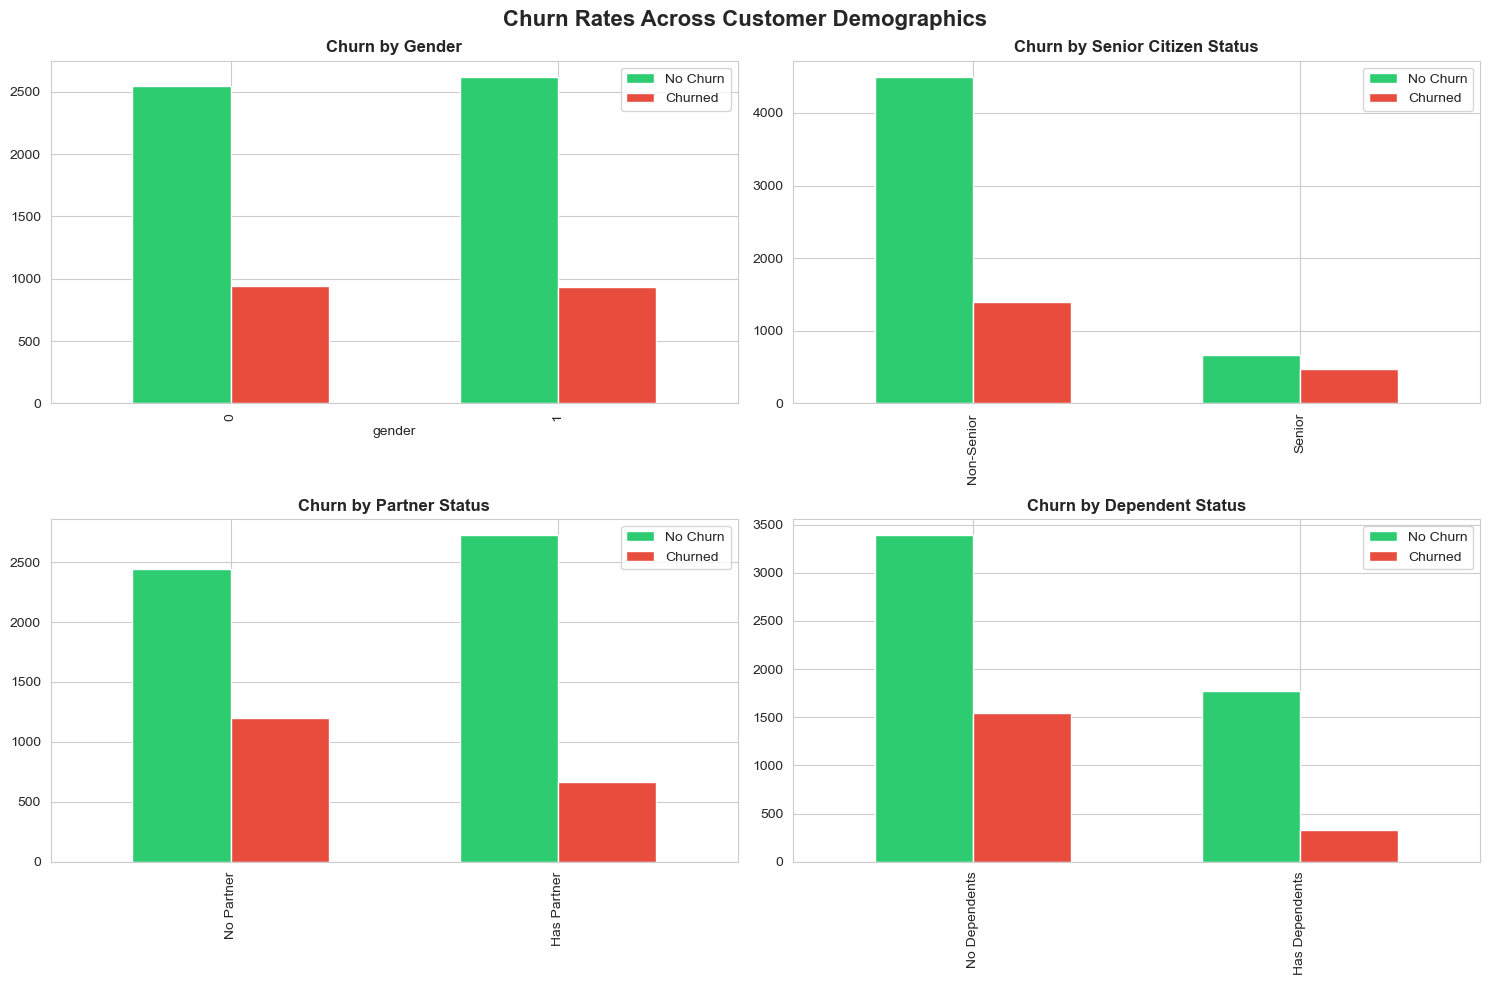


Churn Rates Summary:
By Gender: {0: 26.96, 1: 26.2}
Senior Citizen: 41.68%
Has Partner: 19.72%
Has Dependents: 15.53%


In [91]:
sns.set_style("whitegrid")

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Churn Rates Across Customer Demographics', fontsize=16, fontweight='bold')

# 1. GENDER
gender_churn = df.groupby('gender')['churn'].agg(['sum', 'count'])
gender_churn['churn_rate'] = (gender_churn['sum'] / gender_churn['count'] * 100).round(2)
churn_counts = df.groupby('gender')['churn'].value_counts().unstack()
churn_counts.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'], width=0.6)
axes[0, 0].set_title('Churn by Gender', fontweight='bold')
axes[0, 0].legend(['No Churn', 'Churned'])

# 2. SENIOR CITIZEN
churn_senior = df.groupby('seniorcitizen')['churn'].value_counts().unstack()
churn_senior.index = ['Non-Senior', 'Senior']
churn_senior.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'], width=0.6)
axes[0, 1].set_title('Churn by Senior Citizen Status', fontweight='bold')
axes[0, 1].legend(['No Churn', 'Churned'])

# 3. PARTNER
churn_partner = df.groupby('partner')['churn'].value_counts().unstack()
churn_partner.index = ['No Partner', 'Has Partner']
churn_partner.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'], width=0.6)
axes[1, 0].set_title('Churn by Partner Status', fontweight='bold')
axes[1, 0].legend(['No Churn', 'Churned'])

# 4. DEPENDENTS
churn_dependents = df.groupby('dependents')['churn'].value_counts().unstack()
churn_dependents.index = ['No Dependents', 'Has Dependents']
churn_dependents.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'], width=0.6)
axes[1, 1].set_title('Churn by Dependent Status', fontweight='bold')
axes[1, 1].legend(['No Churn', 'Churned'])



plt.tight_layout()
plt.show()

# Print churn rates
print("\nChurn Rates Summary:")
print(f"By Gender: {(gender_churn['churn_rate']).to_dict()}")
print(f"Senior Citizen: {(df[df['seniorcitizen']==1]['churn'].mean() * 100):.2f}%")
print(f"Has Partner: {(df[df['partner']==1]['churn'].mean() * 100):.2f}%")
print(f"Has Dependents: {(df[df['dependents']==1]['churn'].mean() * 100):.2f}%")

#### Churn in relation to service features

This section analyzes churn rates based on service-related variables:

- internet service
- technical support
- online security

In [92]:
df_service = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Standardize column names
df_service.columns = df_service.columns.str.strip().str.lower()

# Clean totalcharges
df_service["totalcharges"] = df_service["totalcharges"].replace(" ", pd.NA)
df_service["totalcharges"] = pd.to_numeric(df_service["totalcharges"])
df_service = df_service.dropna()


Churn by internetservice:
churn              No   Yes
internetservice            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4

Churn by techsupport:
churn                  No   Yes
techsupport                    
No                   58.4  41.6
No internet service  92.6   7.4
Yes                  84.8  15.2

Churn by onlinesecurity:
churn                  No   Yes
onlinesecurity                 
No                   58.2  41.8
No internet service  92.6   7.4
Yes                  85.4  14.6


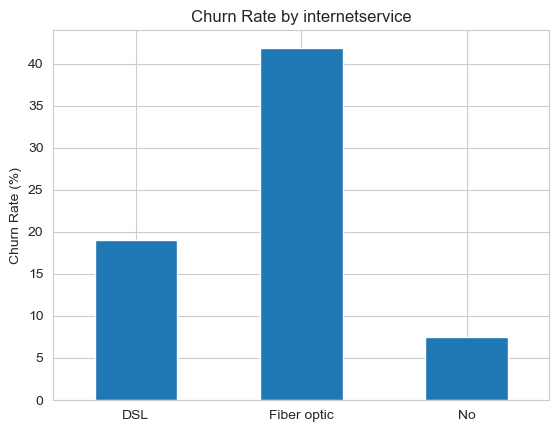

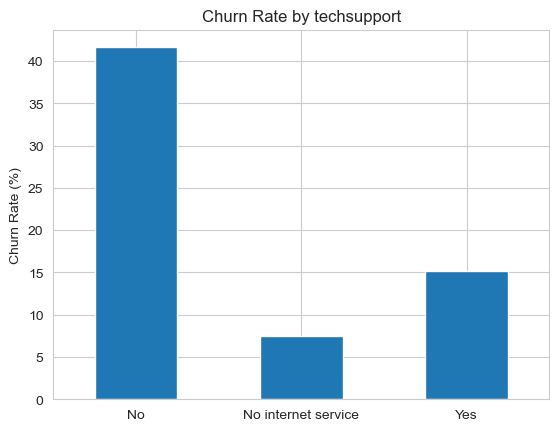

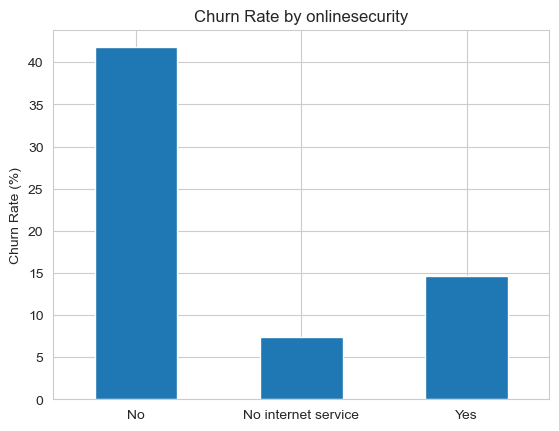

In [93]:
service_cols = ["internetservice", "techsupport", "onlinesecurity"]

for col in service_cols:
    print(f"\nChurn by {col}:")
    print(
        pd.crosstab(
            df_service[col],
            df_service["churn"],
            normalize="index"
        ).round(3) * 100
    )

for col in service_cols:
    churn_rate = (
        pd.crosstab(df_service[col], df_service["churn"], normalize="index")["Yes"] * 100
    )

    churn_rate.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate (%)")
    plt.xlabel("")
    plt.xticks(rotation=0)
    plt.show()

#### Churn by contract type

This chart compares churn rates across different contract types.

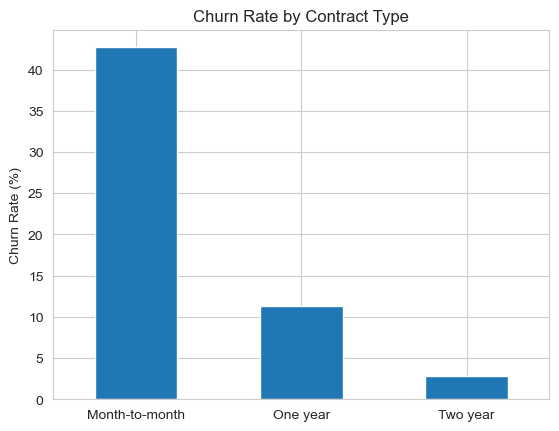

In [94]:
contract_churn = (
    pd.crosstab(df_service["contract"], df_service["churn"], normalize="index")["Yes"] * 100
)

contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()

#### Customer tenure vs churn

This boxplot compares customer tenure between churned and retained customers.

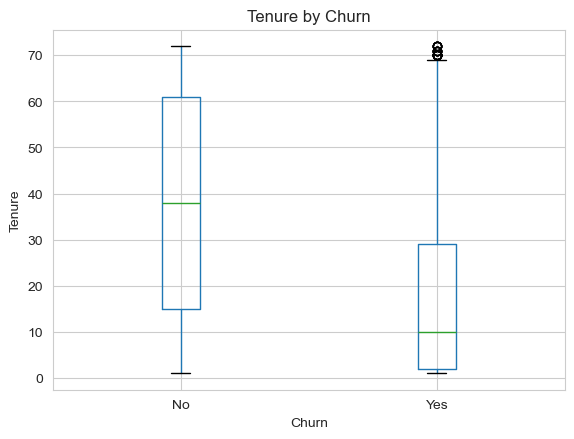

In [95]:
df_service.boxplot(column="tenure", by="churn")

plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

#### Monthly charges vs churn

This boxplot compares monthly charges between churned and retained customers.

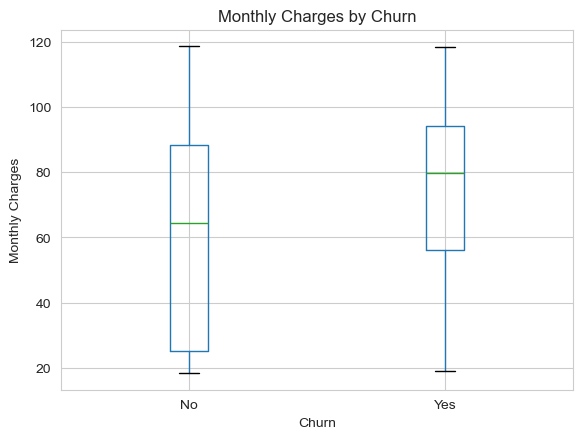

In [96]:
df_service.boxplot(column="monthlycharges", by="churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


### ----------------Machine Learning Modeling ----------------

    This section builds and evaluates multiple machine learning models for customer churn prediction.

Models used:
- Logistic Regression
- Random Forest
- XGBoost

 1. Logistic Regression

    Logistic Regression is used as a baseline binary classification model.

In [77]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


2. Random Forest

    Random Forest is an ensemble learning model that combines multiple decision trees.

In [78]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


 3. XGBoost

    XGBoost is an advanced boosting algorithm that often performs well on structured tabular data.

In [79]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


Model Evaluation

    The models are evaluated using:
        Accuracy
        Precision
        Recall
        F1-score

In [80]:
# Predictions
y_pred_log = model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Results table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results = results.round(4)
print(results)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8038     0.6476  0.5749    0.6091
1        Random Forest    0.7903     0.6330  0.5027    0.5604
2              XGBoost    0.7967     0.6375  0.5455    0.5879


Performance Comparison Visualization

    This chart compares the performance of all models across the evaluation metrics.

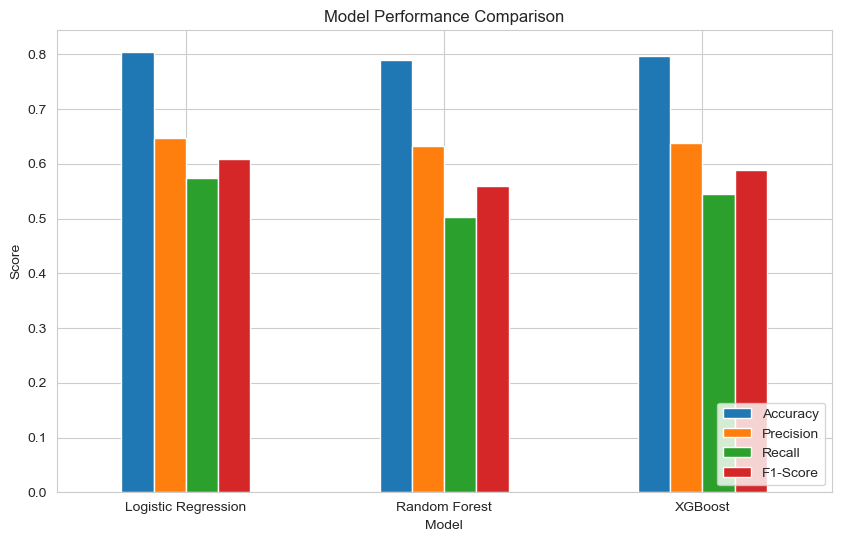

In [62]:
results.set_index("Model").plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

 Feature Importance

    Feature importance helps identify the most influential variables in predicting customer churn.

    The ranking below uses the Random Forest model. 

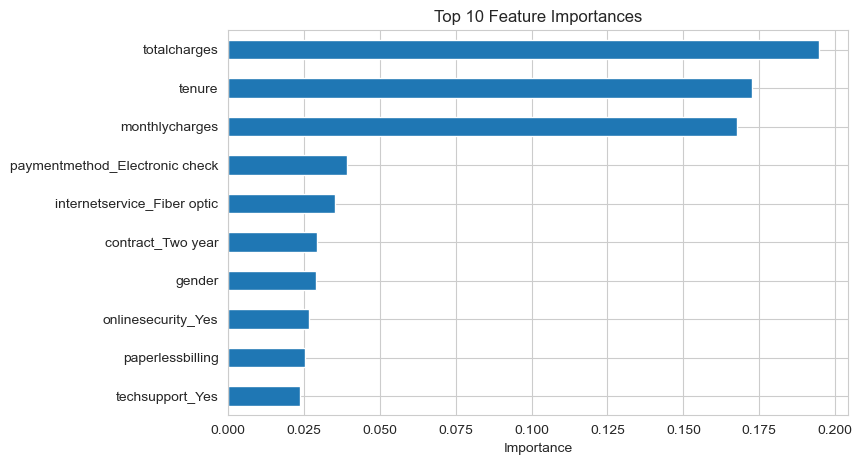

In [81]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

top_features = feature_importance.head(10)

top_features.sort_values("Importance").plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False,
    figsize=(8, 5)
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

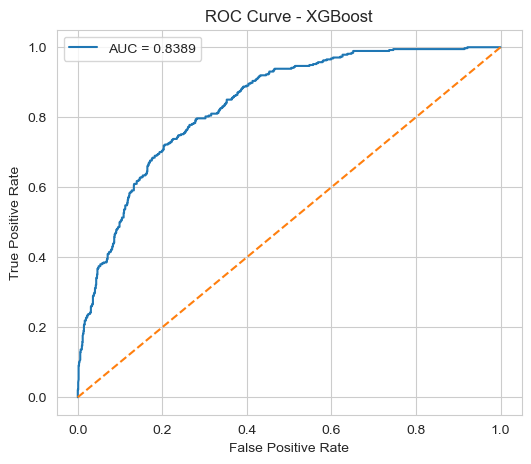

In [83]:
## ROC Curve

# Predict probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# AUC score
auc_score = roc_auc_score(y_test, y_prob_xgb)

# Plot ROC curve
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

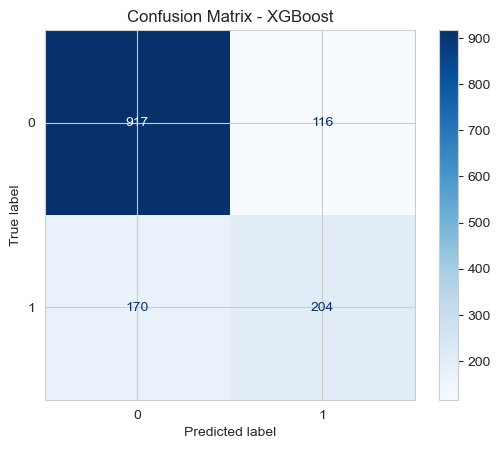

In [82]:
## Confusion Matrix
import matplotlib.pyplot as plt

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - XGBoost")
plt.show()

## Conclusion
Recommended Model Report Based on the evaluation results, Logistic Regression is the recommended model for customer churn prediction .
#### Why Logistic Regression?
logistic Regression achieved the best overall performance across all evaluation metrics :

    - highest accuracy
    - highest precision
    - highest recall
    - highest F1-score

## What we should do to improve the business 

#### Calculate the average revenue loss per churned customer

In [87]:
if df["churn"].dtype == "object":
    churned_customers = df[df["churn"].str.lower() == "yes"]
else:
    churned_customers = df[df["churn"] == 1]

# Calculate average monthly revenue loss
avg_monthly_loss = churned_customers["monthlycharges"].mean()

# Calculate average total revenue loss
avg_total_loss = churned_customers["totalcharges"].mean()

# Number of churned customers
num_churned = churned_customers.shape[0]

# Estimated total monthly churn loss
total_monthly_loss = avg_monthly_loss * num_churned

# Display results
print("Churn Cost Simulation")
print("-" * 40)

print(f"Number of churned customers: {num_churned}")

print(f"\nAverage monthly revenue loss per churned customer: "
      f"${avg_monthly_loss:.2f}")

print(f"Average total revenue loss per churned customer: "
      f"${avg_total_loss:.2f}")

print(f"\nEstimated total monthly revenue loss from churn: "
      f"${total_monthly_loss:,.2f}")



# Select churned customers

if (df["churn"].dtype == "object") :
    churned_customers = df[df["churn"].str.lower() == "yes"]
else:
    churned_customers = df[df["churn"] == 1]

# Basic metrics
num_churned = len(churned_customers)

avg_monthly_revenue = churned_customers["monthlycharges"].mean()

print("Average monthly revenue per churned customer:",round(avg_monthly_revenue, 2))

print("Total churned customers:", num_churned)

Churn Cost Simulation
----------------------------------------
Number of churned customers: 1869

Average monthly revenue loss per churned customer: $74.44
Average total revenue loss per churned customer: $1531.80

Estimated total monthly revenue loss from churn: $139,130.85
Average monthly revenue per churned customer: 74.44
Total churned customers: 1869


#### using Discount Offer strategy to retention the customers
    Assumptions:
    - 20% discount offered
    - 30% of churned customers are retained

In [88]:
discount_rate = 0.20
retention_rate_discount = 0.30

# Customers retained
retained_discount = int(num_churned * retention_rate_discount)

# Revenue saved
saved_revenue_discount = retained_discount * avg_monthly_revenue

# Cost of discounts
discount_cost = saved_revenue_discount * discount_rate

# Net gain
net_gain_discount = saved_revenue_discount - discount_cost

print("DISCOUNT STRATEGY")
print("-" * 30)

print("Customers retained:", retained_discount)

print(f"Revenue saved: ${saved_revenue_discount:,.2f}")

print(f"Discount cost: ${discount_cost:,.2f}")

print(f"Net gain: ${net_gain_discount:,.2f}")



DISCOUNT STRATEGY
------------------------------
Customers retained: 560
Revenue saved: $41,687.15
Discount cost: $8,337.43
Net gain: $33,349.72


In [89]:
## Strategy 2: Loyalty Perks

#Assumptions:
#- Loyalty perks cost $10 per customer
#- 25% of churned customers are retained

# Strategy assumptions
retention_rate_loyalty = 0.25
perk_cost_per_customer = 10

# Customers retained
retained_loyalty = int(num_churned * retention_rate_loyalty)

# Revenue saved
saved_revenue_loyalty = retained_loyalty * avg_monthly_revenue

# Loyalty program cost
loyalty_cost = retained_loyalty * perk_cost_per_customer

# Net gain
net_gain_loyalty = saved_revenue_loyalty - loyalty_cost

print("LOYALTY PERKS STRATEGY")
print("-" * 30)

print("Customers retained:", retained_loyalty)

print(f"Revenue saved: ${saved_revenue_loyalty:,.2f}")

print(f"Loyalty cost: ${loyalty_cost:,.2f}")

print(f"Net gain: ${net_gain_loyalty:,.2f}")

LOYALTY PERKS STRATEGY
------------------------------
Customers retained: 467
Revenue saved: $34,764.10
Loyalty cost: $4,670.00
Net gain: $30,094.10


### We can segment Customer to : 
+ High-Risk + High-Value
+ High-Risk + Low-Value
+ Low-Risk + High-Value
+ Low-Risk + Low-Value

customer_segment
Low Risk + Low Value      2930
Low Risk + High Value     2519
High Risk + High Value    1402
High Risk + Low Value      181
Name: count, dtype: int64


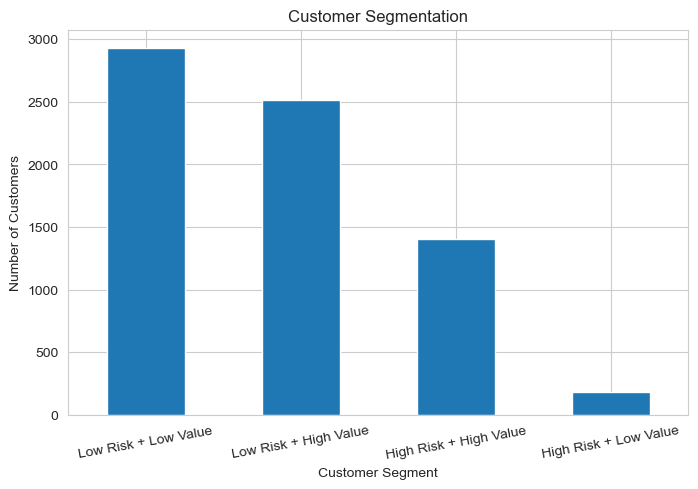

In [90]:
# Copy dataframe
seg_df = df.copy()

# Scale the full feature dataset
X_scaled = scaler.transform(X)

# Predict churn probabilities
seg_df["churn_probability"] = model.predict_proba(X_scaled)[:, 1]

# -------------------------------
# Customer Value Segmentation
# -------------------------------

avg_value = seg_df["monthlycharges"].mean()

seg_df["value_segment"] = np.where(
    seg_df["monthlycharges"] >= avg_value,
    "High Value",
    "Low Value"
)

# -------------------------------
# Churn Risk Segmentation
# -------------------------------

seg_df["risk_segment"] = np.where(
    seg_df["churn_probability"] >= 0.5,
    "High Risk",
    "Low Risk"
)

# -------------------------------
# Combine Segments
# -------------------------------

seg_df["customer_segment"] = (
    seg_df["risk_segment"] + " + " + seg_df["value_segment"]
)

# Count customers in each segment
segment_counts = seg_df["customer_segment"].value_counts()

# Show results
print(segment_counts)


plt.figure(figsize=(8,5))

segment_counts.plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=10)

plt.show()